# Assignment 1 2AMM10 2025-2026

## Group: Evangelist
### Member 1: Joan Lleo
### Member 2: Giorgio Maria Maioli
### Member 3: Evangelos Matzavinos


In [24]:
!pip install torch pandas pathlib matplotlib numpy torch_geometric scikit-learn

In [3]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

# Task 1

In [4]:
import subprocess
import sys
import torch_geometric

class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]




train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

<Axes: >

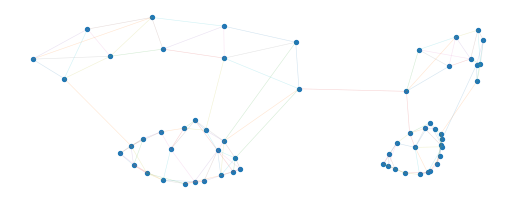

In [5]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

In [6]:
# ── Task 1 EDA ──────────────────────────────────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

# ── 1. Collect per-graph statistics ─────────────────────────────────────────
def collect_stats(dataset):
    labels, n_nodes, n_edges = [], [], []
    all_coords, edge_dists_per_class = [], {0: [], 1: []}
    eye_open_per_class = {0: [], 1: []}

    for g in dataset:
        y = int(g.y.item())
        labels.append(y)
        n_nodes.append(g.x.shape[0])
        # edge_index is (2, E) – may contain both directions; count unique
        n_edges.append(g.edge_index.shape[1])
        all_coords.append(g.x)

        # Edge distances: ||x_i – x_j||  (the key geometric invariant)
        src, dst = g.edge_index[0], g.edge_index[1]
        diffs = g.x[src] - g.x[dst]                   # (E, 3)
        dists = diffs.norm(dim=-1).numpy()             # (E,)
        edge_dists_per_class[y].extend(dists.tolist())

        # eye_openness attribute (useful sanity-check, not used as model input)
        if hasattr(g, 'eye_openness') and g.eye_openness is not None:
            eye_open_per_class[y].append(float(g.eye_openness))

    coords = torch.cat(all_coords, dim=0).numpy()     # (total_nodes, 3)
    return labels, n_nodes, n_edges, coords, edge_dists_per_class, eye_open_per_class

train_labels, tr_nodes, tr_edges, tr_coords, tr_dists, tr_eye = collect_stats(train_dataset)
test_labels,  te_nodes, te_edges, te_coords, te_dists, te_eye = collect_stats(test_dataset)

# ── 2. Print summary table ───────────────────────────────────────────────────
def print_stats(labels, n_nodes, n_edges, coords, split):
    cnt = Counter(labels)
    print(f"\n{'─'*45}")
    print(f"  {split} split  ({len(labels)} graphs)")
    print(f"{'─'*45}")
    for cls_id, cls_name in id_to_class.items():
        print(f"  class {cls_id} ({cls_name:<8}): {cnt[int(cls_id)]:>4}  "
              f"({100*cnt[int(cls_id)]/len(labels):.1f}%)")
    print(f"\n  Nodes/graph : min={min(n_nodes)} max={max(n_nodes)} "
          f"mean={np.mean(n_nodes):.1f}  (all same: {len(set(n_nodes))==1})")
    print(f"  Edges/graph : min={min(n_edges)} max={max(n_edges)} "
          f"mean={np.mean(n_edges):.1f}  (all same: {len(set(n_edges))==1})")
    print(f"\n  Coordinate ranges (normalized):")
    for ax_i, ax_name in enumerate(['x','y','z']):
        print(f"    {ax_name}: [{coords[:,ax_i].min():.3f}, {coords[:,ax_i].max():.3f}]"
              f"  mean={coords[:,ax_i].mean():.3f}  std={coords[:,ax_i].std():.3f}")

print_stats(train_labels, tr_nodes, tr_edges, tr_coords, "TRAIN")
print_stats(test_labels,  te_nodes, te_edges, te_coords, "TEST ")



─────────────────────────────────────────────
  TRAIN split  (400 graphs)
─────────────────────────────────────────────
  class 0 (awake   ):  200  (50.0%)
  class 1 (drowsy  ):  200  (50.0%)

  Nodes/graph : min=60 max=60 mean=60.0  (all same: True)
  Edges/graph : min=272 max=328 mean=298.6  (all same: False)

  Coordinate ranges (normalized):
    x: [-0.827, 0.836]  mean=0.018  std=0.352
    y: [-0.896, 0.672]  mean=-0.339  std=0.248
    z: [-0.472, 0.609]  mean=0.002  std=0.162

─────────────────────────────────────────────
  TEST  split  (100 graphs)
─────────────────────────────────────────────
  class 0 (awake   ):   50  (50.0%)
  class 1 (drowsy  ):   50  (50.0%)

  Nodes/graph : min=60 max=60 mean=60.0  (all same: True)
  Edges/graph : min=278 max=320 mean=297.3  (all same: False)

  Coordinate ranges (normalized):
    x: [-0.807, 0.751]  mean=-0.019  std=0.350
    y: [-0.911, 0.781]  mean=-0.316  std=0.273
    z: [-0.463, 0.627]  mean=-0.014  std=0.166


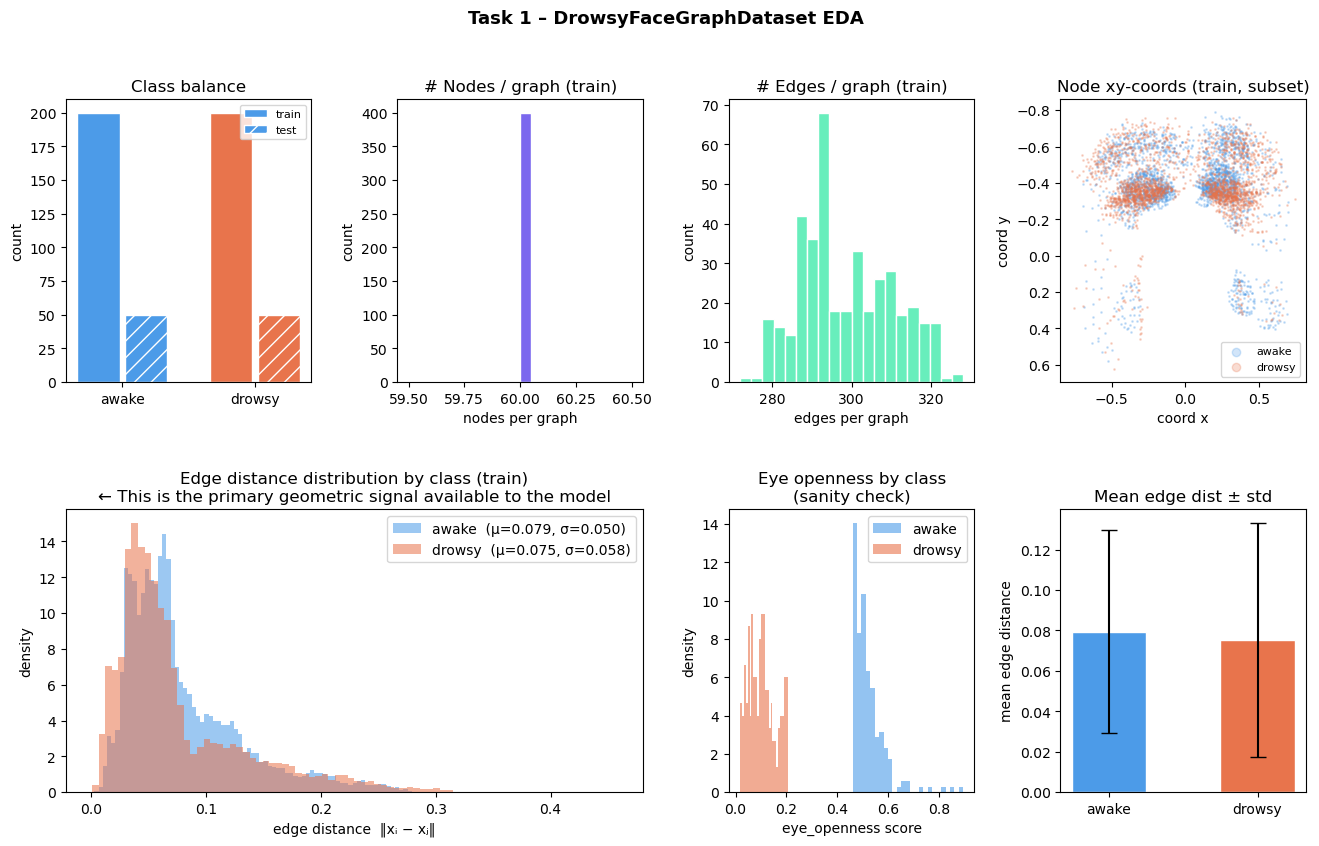

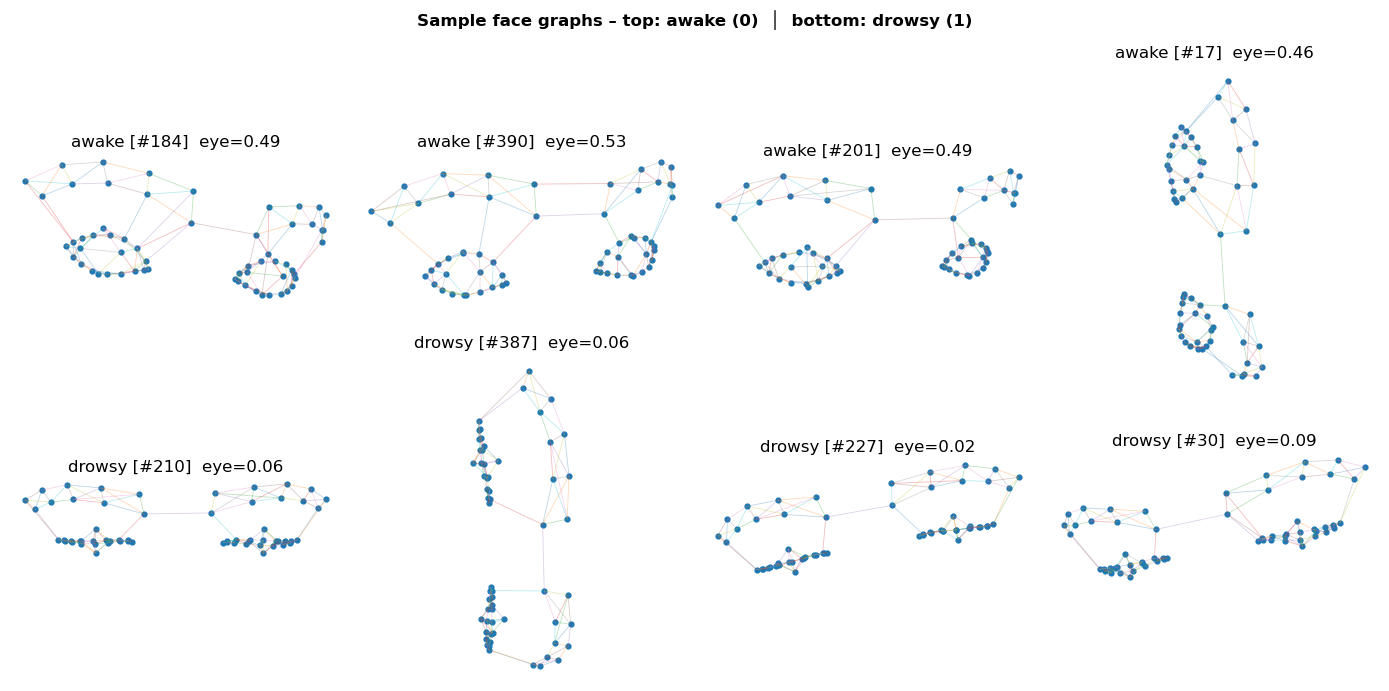

In [7]:
# ── 3. Figure 1 – Overview ───────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

colors = {0: '#4C9BE8', 1: '#E8744C'}
label_names = {0: 'awake', 1: 'drowsy'}

# 3a  Class balance – train vs test
ax_cls = fig.add_subplot(gs[0, 0])
cnt_tr = Counter(train_labels)
cnt_te = Counter(test_labels)
x_pos  = np.arange(2)
for split_cnt, offset, hatch, lbl in [
        (cnt_tr, -0.18, '', 'train'),
        (cnt_te,  0.18, '//', 'test')]:
    ax_cls.bar(x_pos + offset,
               [split_cnt[0], split_cnt[1]],
               width=0.32, color=[colors[0], colors[1]],
               hatch=hatch, edgecolor='white', label=lbl)
ax_cls.set_xticks([0,1]); ax_cls.set_xticklabels(['awake','drowsy'])
ax_cls.set_ylabel('count'); ax_cls.set_title('Class balance')
ax_cls.legend(fontsize=8)

# 3b  Nodes per graph (train)
ax_nodes = fig.add_subplot(gs[0, 1])
ax_nodes.hist(tr_nodes, bins=20, color='#7B68EE', edgecolor='white')
ax_nodes.set_xlabel('nodes per graph'); ax_nodes.set_ylabel('count')
ax_nodes.set_title('# Nodes / graph (train)')

# 3c  Edges per graph (train)
ax_edges = fig.add_subplot(gs[0, 2])
ax_edges.hist(tr_edges, bins=20, color='#68EEBC', edgecolor='white')
ax_edges.set_xlabel('edges per graph'); ax_edges.set_ylabel('count')
ax_edges.set_title('# Edges / graph (train)')

# 3d  3D coordinate scatter (x vs y, colour by class)
ax_xy = fig.add_subplot(gs[0, 3])
for cls in [0, 1]:
    mask = np.array(train_labels) == cls
    sample_idx = np.where(mask)[0]
    # collect a subset of node coords from graphs of this class
    pts = []
    for g_idx in sample_idx[:40]:   # 40 graphs × nodes
        pts.append(train_dataset[g_idx].x[:, :2].numpy())
    pts = np.concatenate(pts, 0)
    ax_xy.scatter(pts[:,0], pts[:,1], s=1, alpha=0.25,
                  c=colors[cls], label=label_names[cls])
ax_xy.set_xlabel('coord x'); ax_xy.set_ylabel('coord y')
ax_xy.set_title('Node xy-coords (train, subset)')
ax_xy.invert_yaxis(); ax_xy.legend(markerscale=6, fontsize=8)

# 3e  Edge-distance histogram split by class (MOST IMPORTANT FOR GNN DESIGN)
ax_dist = fig.add_subplot(gs[1, 0:2])
for cls in [0, 1]:
    d = np.array(tr_dists[cls])
    ax_dist.hist(d, bins=80, alpha=0.55, density=True,
                 color=colors[cls], label=f"{label_names[cls]}  "
                 f"(μ={d.mean():.3f}, σ={d.std():.3f})")
ax_dist.set_xlabel('edge distance  ‖xᵢ − xⱼ‖')
ax_dist.set_ylabel('density')
ax_dist.set_title('Edge distance distribution by class (train)\n'
                  '← This is the primary geometric signal available to the model')
ax_dist.legend()

# 3f  Eye openness by class (sanity check – not used as model input)
ax_eye = fig.add_subplot(gs[1, 2])
for cls in [0, 1]:
    vals = tr_eye[cls]
    if vals:
        ax_eye.hist(vals, bins=25, alpha=0.6, density=True,
                    color=colors[cls], label=label_names[cls])
ax_eye.set_xlabel('eye_openness score')
ax_eye.set_ylabel('density')
ax_eye.set_title('Eye openness by class\n(sanity check)')
ax_eye.legend()

# 3g  Mean ± std of edge distances per class (bar)
ax_dbar = fig.add_subplot(gs[1, 3])
means = [np.mean(tr_dists[c]) for c in [0,1]]
stds  = [np.std(tr_dists[c])  for c in [0,1]]
ax_dbar.bar([0,1], means, yerr=stds, color=[colors[0],colors[1]],
            capsize=6, edgecolor='white', width=0.5)
ax_dbar.set_xticks([0,1]); ax_dbar.set_xticklabels(['awake','drowsy'])
ax_dbar.set_ylabel('mean edge distance'); ax_dbar.set_title('Mean edge dist ± std')

plt.suptitle('Task 1 – DrowsyFaceGraphDataset EDA', fontsize=13, fontweight='bold')
plt.show()

# ── 4. Figure 2 – Face graph gallery ────────────────────────────────────────
import random

def get_samples_by_class(dataset, labels, cls, n=4, seed=0):
    rng = random.Random(seed)
    idxs = [i for i,l in enumerate(labels) if l == cls]
    return rng.sample(idxs, min(n, len(idxs)))

fig2, axes = plt.subplots(2, 4, figsize=(14, 7))
fig2.suptitle('Sample face graphs – top: awake (0)  │  bottom: drowsy (1)',
              fontsize=12, fontweight='bold')

for row, cls in enumerate([0, 1]):
    for col, idx in enumerate(get_samples_by_class(train_dataset, train_labels, cls, n=4)):
        ax = axes[row][col]
        g  = train_dataset[idx]
        eye_str = (f"  eye={float(g.eye_openness):.2f}"
                   if hasattr(g,'eye_openness') and g.eye_openness is not None else "")
        plot_face_graph(g, ax=ax,
                        title=f"{label_names[cls]} [#{idx}]{eye_str}",
                        node_size=12, edge_alpha=0.3, edge_width=0.6)

plt.tight_layout()
plt.show()

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 – Imports & preprocessing
# ══════════════════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data   import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn     import MessagePassing, global_mean_pool
from torch_geometric.utils  import degree
from torchinfo import summary
from sklearn.metrics        import precision_score, recall_score, confusion_matrix


def add_edge_distances(g):
    """
    Replace graph node features with E(3)-invariant edge distances.
    
    The raw coordinates g.x are NOT E(3)-invariant (they change under
    rotation/translation). We compute d_ij = ||x_i - x_j|| for every edge,
    which IS invariant to the full Euclidean group E(3): rotations,
    translations, and reflections all leave pairwise distances unchanged.
    We store these as edge_attr so the model never sees raw coordinates.
    """
    src, dst = g.edge_index
    dist = (g.x[src] - g.x[dst]).norm(dim=-1, keepdim=True)   # (E, 1)
    return Data(
        x          = g.x,            # kept for reference but NOT used as model input
        edge_index = g.edge_index,
        edge_attr  = dist,           # (E, 1)  ← the only geometric input to the model
        y          = g.y,
    )


train_graphs = [add_edge_distances(g) for g in train_dataset]
test_graphs  = [add_edge_distances(g) for g in test_dataset]

# PyG's DataLoader batches graphs via Batch.from_data_list, handling
# variable edge counts automatically and adding a `batch` vector that
# maps each node to its graph index (needed for global_mean_pool).
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True,  drop_last=False)
test_loader  = DataLoader(test_graphs,  batch_size=32, shuffle=False, drop_last=False)

print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")
print(f"Sample edge_attr shape: {train_graphs[0].edge_attr.shape}")

Train batches: 13  |  Test batches: 4
Sample edge_attr shape: torch.Size([304, 1])


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 – Model definition
# ══════════════════════════════════════════════════════════════════════════════

class DistanceConv(nn.Module):
    """
    A single E(3)-invariant message passing layer (implemented from scratch).

    The symmetry argument:
      - Message m_ij = MLP(h_i, h_j, d_ij)
            h_i, h_j are invariant by induction (see node init).
            d_ij = ||x_i - x_j|| is E(3)-invariant.
            → m_ij is invariant.
      - Aggregation  m_i = Σ_{j∈N(i)} m_ij
            Sum over an unordered neighbourhood = permutation-invariant.
            → m_i is invariant.
      - Update  h_i' = LayerNorm(m_i + W·h_i)
            Both terms invariant → h_i' invariant.

    After stacking K such layers, every node embedding h_i^K is E(3)- and
    permutation-invariant. Global mean-pool over nodes then gives a
    graph-level embedding that is invariant to both symmetries.
    """

    def __init__(self, emb_dim: int, activation = nn.SiLU()):
        super().__init__()

        self.edge_network = nn.Sequential(nn.Linear(2*emb_dim+1, emb_dim),
                                          activation,
                                          nn.Linear(emb_dim, emb_dim),
                                          activation
                                          )
        
        self.node_network = nn.Sequential(nn.Linear(2*emb_dim, emb_dim),
                                          activation,
                                          nn.Linear(emb_dim, emb_dim),
                                          activation
                                          )

        # Post-aggregation normalisation + skip connection
        self.norm = nn.LayerNorm(emb_dim)
        self.res  = nn.Identity()  # residual connection (h_i → h_i')

    def forward(self, x, edge_index, edge_attr):

        src, dest = edge_index[0], edge_index[1]

        h_i = x[dest]   # (E, emb_dim)  – receiver node features
        h_j = x[src]    # (E, emb_dim)  – sender node features
        d_ij = edge_attr # (E, 1)        – edge distances

        msg = self.edge_network(torch.cat([h_i, h_j, d_ij], dim=-1))  # (E, 2*emb_dim + 1) -> (E, emb_dim)

        node_agg_messages = torch.zeros(x.size(0), x.size(1)).to(x.device)
        node_agg_messages = node_agg_messages.scatter_add_(
            dim=0, index=edge_index[1].unsqueeze(-1).expand(-1, x.size(1)), src=msg
        )

        node_update = self.node_network(torch.cat([x, node_agg_messages], dim=-1))
        
        node_out = self.norm(node_update + self.res(x))  # (N, emb_dim)

        return node_out



        
    

class DrowsinessGNN(nn.Module):
    """
    E(3)-invariant GNN for binary drowsiness classification.

    Architecture:
        invariant node init  →  K × DistanceConv  →  global mean pool  →  MLP head

    Node initialisation:
        Raw coordinates x_i are NOT E(3)-invariant, so we never feed them to
        the network. Instead we seed each node with two invariant scalars:
          • mean_d:  mean L2 distance to graph neighbours  (function of d_ij only)
          • deg_n:   normalised node degree                 (graph topology, no geometry)
        Both are invariant under any rigid motion of the point cloud.
    """

    def __init__(self, hidden_dim: int = 64, n_layers: int = 3, dropout: float = 0.1, activation = nn.SiLU()):
        super().__init__()

        # ── Embedding layer ──
        self.node_encoder = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # ── Message passing stack ──
        self.convs   = nn.ModuleList([
            DistanceConv(hidden_dim, activation) for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)

        # ── Binary classification head ──
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, data):
        x, ei, ea, batch = data.x, data.edge_index, data.edge_attr, data.batch
        N = x.size(0)
        d = ea.squeeze(-1)                                           # (E,)

        # ── Create invariant features (mean and degree) ──
        deg  = degree(ei[0], num_nodes=N, dtype=torch.float)        # (N,)
        sum_d = torch.zeros(N, device=d.device)
        sum_d.index_add_(0, ei[0], d)
        mean_d = (sum_d / deg.clamp(min=1)).unsqueeze(-1)           # (N, 1) #Mean distance to neighbors
        deg_n  = (deg / 10.).unsqueeze(-1)                          # (N, 1) # Normalised degree (to keep in a similar range as mean_d)

        h = self.node_encoder(torch.cat([mean_d, deg_n], dim=-1))   # (N, H) #Embed mean_d and deg_n

        # ── Message passing ──
        for conv in self.convs:
            h = self.dropout(conv(h, ei, ea))                       # (N, H)

        # Mean over nodes of the same graph → one vector per graph in the batch
        h_graph = global_mean_pool(h, batch)                        # (B, H)

        return self.head(h_graph).squeeze(-1)                       # (B,) raw logit


# ── Sanity check ──
model = DrowsinessGNN(hidden_dim=64, n_layers=3, dropout=0.1, activation=nn.SiLU()).to(DEVICE)
print(summary(model))

# ── Quick forward pass to verify shapes ──
sample_batch = next(iter(train_loader)).to(DEVICE)
out = model(sample_batch)
print(f"Output shape: {out.shape}  (expected: [{sample_batch.num_graphs}])")

Layer (type:depth-idx)                   Param #
DrowsinessGNN                            --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       192
│    └─SiLU: 2-2                         --
│    └─Linear: 2-3                       4,160
├─ModuleList: 1-2                        --
│    └─DistanceConv: 2-4                 --
│    │    └─Sequential: 3-1              12,480
│    │    └─Sequential: 3-2              12,416
│    │    └─LayerNorm: 3-3               128
│    │    └─Identity: 3-4                --
│    └─DistanceConv: 2-5                 --
│    │    └─Sequential: 3-5              12,480
│    │    └─Sequential: 3-6              12,416
│    │    └─LayerNorm: 3-7               128
│    │    └─Identity: 3-8                --
│    └─DistanceConv: 2-6                 --
│    │    └─Sequential: 3-9              12,480
│    │    └─Sequential: 3-10             12,416
│    │    └─LayerNorm: 3-11              128
│    │    └─Identity: 3-12              

In [72]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 – Training loop with loss logging
# ══════════════════════════════════════════════════════════════════════════════

from tqdm import tqdm


def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    """Single train or eval epoch. Pass optimizer=None for eval."""
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = 0.
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)
            loss   = criterion(logits, batch.y.float())
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


# ── Configuration ──
EPOCHS       = 200
LR           = 1e-3
WEIGHT_DECAY = 1e-4

model     = DrowsinessGNN(hidden_dim=64, n_layers=3, dropout=0.2, activation=nn.SiLU()).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss()

# ── Training ──
train_losses, test_losses = [], []

for epoch in tqdm(range(1, EPOCHS + 1), desc="Training... ", leave=True):
    tr = run_epoch(model, train_loader, criterion, optimizer)
    te = run_epoch(model, test_loader,  criterion)
    train_losses.append(tr)
    test_losses.append(te)
    if epoch % 20 == 0:
        print(f"\nEpoch {epoch:>3}/{EPOCHS}  │  TRAIN LOSS: {tr:.4f}  │  TEST LOSS: {te:.4f}")

# ── Loss curve ───
fig, ax = plt.subplots(figsize=(8, 4))
epochs = range(1, EPOCHS + 1)
ax.plot(epochs, train_losses, label='train loss', color='#4C9BE8', linewidth=1.5)
ax.plot(epochs, test_losses,  label='test loss',  color='#E8744C', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Task 1 – Training & test loss')
ax.legend()
plt.tight_layout()
plt.show()

# ── Save trained model ──
SAVE_PATH = "task1_drowsiness_gnn.pt"

torch.save({
    "model_state": model.state_dict(),
    "hyperparams": {"hidden_dim": 64, "n_layers": 3, "dropout": 0.2, "activation": nn.SiLU()},
    "train_losses": train_losses,
    "test_losses":  test_losses,
}, SAVE_PATH)

print(f"Model saved to {SAVE_PATH}")

Training... :   0%|          | 0/200 [00:00<?, ?it/s]

Training... :  10%|█         | 21/200 [00:03<00:28,  6.31it/s]


Epoch  20/200  │  TRAIN LOSS: 0.2375  │  TEST LOSS: 0.1817


Training... :  14%|█▎        | 27/200 [00:04<00:26,  6.42it/s]


KeyboardInterrupt: 

In [10]:
# ── Load trained model (run this instead of the training cell) ───────────────
SAVE_PATH = "task1_drowsiness_gnn.pt"

checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
hp = checkpoint["hyperparams"]

model = DrowsinessGNN(
    hidden_dim = hp["hidden_dim"],
    n_layers   = hp["n_layers"],
    dropout    = hp["dropout"],
).to(DEVICE)

model.load_state_dict(checkpoint["model_state"])
model.eval()

train_losses = checkpoint["train_losses"]
test_losses  = checkpoint["test_losses"]

print(f"Model loaded from {SAVE_PATH}")
print(f"Trained for {len(train_losses)} epochs  |  "
      f"final test loss: {test_losses[-1]:.4f}")

Model loaded from task1_drowsiness_gnn.pt
Trained for 200 epochs  |  final test loss: 0.1200


/tmp/ipykernel_329439/2742512651.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)


Decision threshold : 0.2
Precision (drowsy) : 1.0000   ← TP / (TP + FP)
Recall    (drowsy) : 0.9600   ← TP / (TP + FN)  [safety-critical]

Confusion matrix:
[[50  0]
 [ 2 48]]


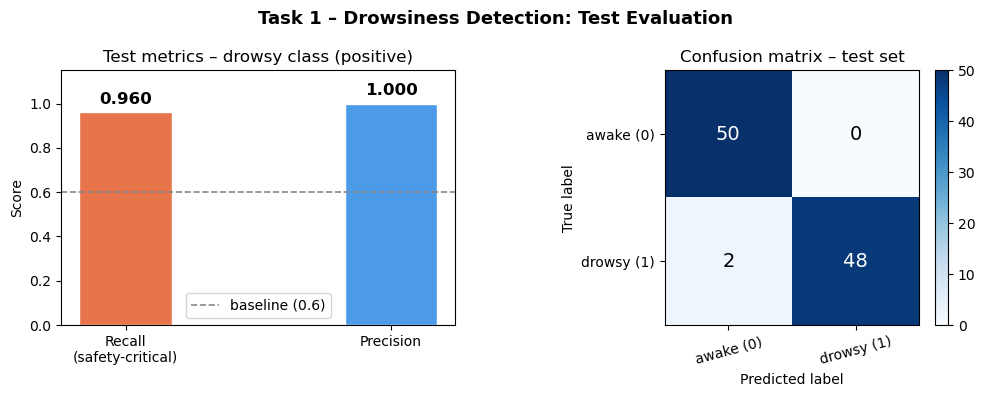

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 – Evaluation & single metrics figure
# ══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def get_predictions(model, loader, device=DEVICE, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        probs = torch.sigmoid(model(batch))
        all_probs.append(probs.cpu())
        all_labels.append(batch.y.cpu())
    probs  = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy().astype(int)
    preds  = (probs >= threshold).astype(int)
    return probs, preds, labels


THRESHOLD = 0.2                               
probs, preds, labels = get_predictions(model, test_loader, threshold=THRESHOLD)

# Positive class = drowsy (1), negative class = awake (0)
precision = precision_score(labels, preds, pos_label=1, zero_division=0)
recall    = recall_score(   labels, preds, pos_label=1, zero_division=0)
cm        = confusion_matrix(labels, preds)

print(f"Decision threshold : {THRESHOLD}")
print(f"Precision (drowsy) : {precision:.4f}   ← TP / (TP + FP)")
print(f"Recall    (drowsy) : {recall:.4f}   ← TP / (TP + FN)  [safety-critical]")
print(f"\nConfusion matrix:\n{cm}")

# ── Plots ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Figure A – Precision & Recall bars
metric_names = ['Recall\n(safety-critical)', 'Precision']
metric_vals  = [recall, precision]
bar_colors   = ['#E8744C', '#4C9BE8']
bars = ax1.bar(metric_names, metric_vals, color=bar_colors, width=0.35, edgecolor='white')
ax1.axhline(0.6, color='#888', linestyle='--', linewidth=1.2, label='baseline (0.6)')
for bar, val in zip(bars, metric_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.025,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Score')
ax1.set_title('Test metrics – drowsy class (positive)')
ax1.legend()

# Figure B – Confusion matrix
im = ax2.imshow(cm, cmap='Blues', vmin=0)
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
tick_labels = ['awake (0)', 'drowsy (1)']
ax2.set_xticks([0, 1]); ax2.set_xticklabels(tick_labels, rotation=15)
ax2.set_yticks([0, 1]); ax2.set_yticklabels(tick_labels)
ax2.set_xlabel('Predicted label')
ax2.set_ylabel('True label')
ax2.set_title('Confusion matrix – test set')
thresh_cm = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax2.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                 color='white' if cm[i, j] > thresh_cm else 'black')

plt.suptitle('Task 1 – Drowsiness Detection: Test Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Model cannot achieve Recall = 1.0 on this test set at any threshold.


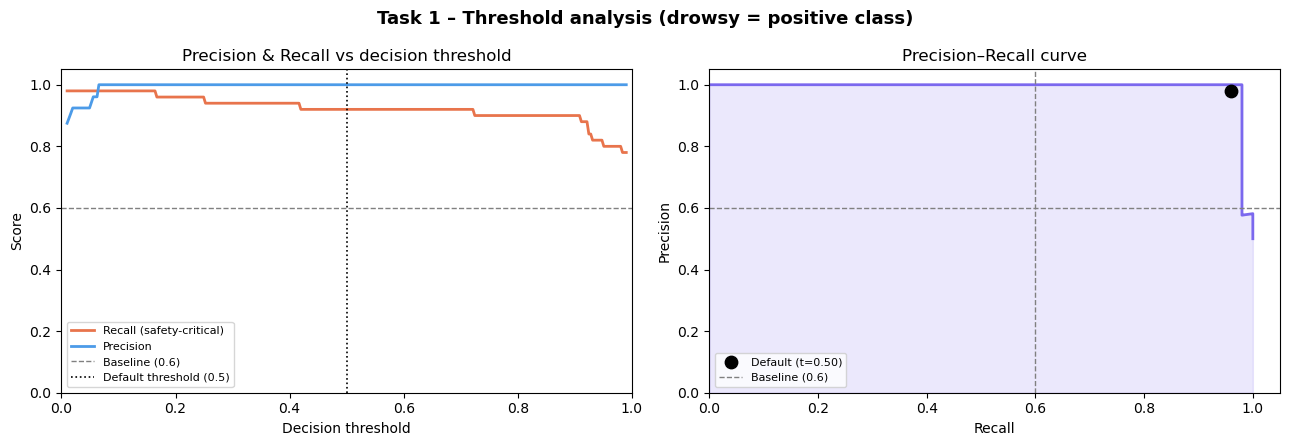

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4.1 – Threshold analysis
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_recall_curve

probs, _, labels = get_predictions(model, test_loader, threshold=0.5)

sk_precisions, sk_recalls, sk_thresholds = precision_recall_curve(labels, probs)


# ── Manual sweep for the threshold-vs-metric plot ──
thresholds  = np.linspace(0.01, 0.99, 300)
precisions  = []
recalls     = []

for t in thresholds:
    p = (probs >= t).astype(int)
    precisions.append(precision_score(labels, p, pos_label=1, zero_division=0))
    recalls.append(   recall_score   (labels, p, pos_label=1, zero_division=0))

precisions = np.array(precisions)
recalls    = np.array(recalls)

# ── Find the highest threshold that still achieves recall = 1.0 ──
# (i.e. catches every single drowsy driver)
full_recall_mask = recalls >= 1.0
if full_recall_mask.any():
    t_safe     = thresholds[full_recall_mask][-1]   # highest t with recall=1
    p_at_safe  = precisions[full_recall_mask][-1]
    print(f"Highest threshold with Recall = 1.0 : {t_safe:.3f}  "
          f"(Precision at that point: {p_at_safe:.3f})")
else:
    print("Model cannot achieve Recall = 1.0 on this test set at any threshold.")
    t_safe = None

# ── Plots ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Figure A – Precision & Recall vs threshold
ax1.plot(thresholds, recalls,    color='#E8744C', linewidth=2, label='Recall (safety-critical)')
ax1.plot(thresholds, precisions, color='#4C9BE8', linewidth=2, label='Precision')
ax1.axhline(0.6,  color='grey', linestyle='--', linewidth=1,   label='Baseline (0.6)')
ax1.axvline(0.5,  color='black', linestyle=':',  linewidth=1.2, label='Default threshold (0.5)')
if t_safe is not None:
    ax1.axvline(t_safe, color='#2ca02c', linestyle='--', linewidth=1.5,
                label=f'Safety threshold ({t_safe:.2f}) → Recall=1.0')
    ax1.scatter([t_safe], [1.0],       color='#E8744C', s=80, zorder=5)
    ax1.scatter([t_safe], [p_at_safe], color='#4C9BE8', s=80, zorder=5)
ax1.set_xlabel('Decision threshold')
ax1.set_ylabel('Score')
ax1.set_title('Precision & Recall vs decision threshold')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=8)

# Figure B – Precision-Recall curve (threshold-free summary)
ax2.plot(sk_recalls, sk_precisions, color='#7B68EE', linewidth=2)
ax2.fill_between(sk_recalls, sk_precisions, alpha=0.15, color='#7B68EE')
ax2.scatter([0.96], [0.98], color='black',   s=80, zorder=5, label='Default (t=0.50)')
if t_safe is not None:
    pr_at_safe = precision_score(labels, (probs >= t_safe).astype(int),
                                 pos_label=1, zero_division=0)
    ax2.scatter([1.0], [pr_at_safe], color='#2ca02c', s=80, zorder=5,
                label=f'Safety (t={t_safe:.2f})')
ax2.axhline(0.6, color='grey', linestyle='--', linewidth=1, label='Baseline (0.6)')
ax2.axvline(0.6, color='grey', linestyle='--', linewidth=1)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision–Recall curve')
ax2.set_xlim(0, 1.05); ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=8)

plt.suptitle('Task 1 – Threshold analysis (drowsy = positive class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print final recommendation ──
if t_safe is not None:
    final_preds = (probs >= t_safe).astype(int)
    final_rec   = recall_score(   labels, final_preds, pos_label=1)
    final_pre   = precision_score(labels, final_preds, pos_label=1, zero_division=0)
    final_cm    = confusion_matrix(labels, final_preds)
    print(f"\n── Safety threshold t = {t_safe:.3f} ──")
    print(f"Recall    : {final_rec:.3f}  (FN = 0 — no drowsy driver missed)")
    print(f"Precision : {final_pre:.3f}")
    print(f"Confusion matrix:\n{final_cm}")

# Task 2

In [63]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

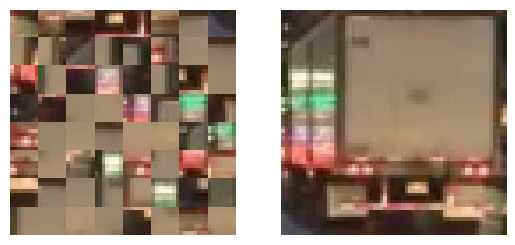

In [100]:



### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt
from torchvision import transforms
from tqdm import tqdm  


train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=Compose([
    Resize((64, 64)),
    ToTensor(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5)
]),
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle()]),  # Fill test image transforms
)


vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)


test_dataset = vis_dataset_noisy  # Use the noisy version for testing
test_dataset_original = vis_dataset_clean  # Keep the clean version for reference

fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

In [101]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 – Preprocessing & dataset definition
# ══════════════════════════════════════════════════════════════════════════════

img, label = train_dataset[0]

print(f"Image shape: {img.shape}  |  Label: {label} \n")

class Patchify:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p
        num_h = h // p
        num_w = w // p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        
        patches = patches.permute(1, 2, 0, 3, 4).contiguous().view(num_h * num_w, c * p * p)

        patches = patches.view(num_h * num_w, c * p * p)  # [num_patches, pixels_per_patch]

        return patches

patchify8 = Patchify(patch_size=8)

train_data = [(patchify8(img), label) for (img, label) in train_dataset]
test_data = [(patchify8(img), label) for (img, label) in test_dataset]

batch_size = 32

train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4)

print(f"Number of training batches: {len(train_dataloader)}, with size {next(iter(train_dataloader))[0].shape} [patches, n_patches, pixels_per_patch] per image")
print(f"Number of test batches: {len(test_dataloader)}, with size {next(iter(test_dataloader))[0].shape} [patches, n_patches, pixels_per_patch] per image")

Image shape: torch.Size([3, 64, 64])  |  Label: 2 

Number of training batches: 75, with size torch.Size([32, 64, 192]) [patches, n_patches, pixels_per_patch] per image
Number of test batches: 8, with size torch.Size([32, 64, 192]) [patches, n_patches, pixels_per_patch] per image


In [102]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 – Model definition
# ══════════════════════════════════════════════════════════════════════════════

class PatchEmbedder(nn.Module):
    def __init__(self, input_dim=192, emb_dim=64):
        super().__init__()
        self.mlp = nn.Linear(input_dim, emb_dim)

    def forward(self, x):

        return self.mlp(x)  # [B, num_patches, emb_dim]
    

class AttentionBlock(nn.Module):
    def __init__(self, emb_dim=64, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(emb_dim, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim * 4, emb_dim)
        )

    def forward(self, x):
        # x: [B, num_patches, emb_dim]
        attn_out, _ = self.attn(x, x, x)  # Self-attention
        x = self.norm1(x + attn_out)       # Add & norm
        ffn_out = self.ffn(x)              # Feed-forward
        return self.norm2(x + ffn_out)     # Add & norm
    

class PatchTransformer(nn.Module):
    def __init__(self, input_dim=192, emb_dim=64, num_heads=4, num_layers=3, num_classes=10, dropout=0.1):
        super().__init__()
        self.embedder = PatchEmbedder(input_dim, emb_dim)
        self.layers = nn.ModuleList([
            AttentionBlock(emb_dim, num_heads, dropout) for _ in range(num_layers)
        ])
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        # x: [B, num_patches, pixels_per_patch]
        x = self.embedder(x)  # [B, num_patches, emb_dim]
        for layer in self.layers:
            x = layer(x)       # [B, num_patches, emb_dim]
        x = x.mean(dim=1)     # Global average pooling over patches
        return self.classifier(x)  # [B, num_classes]
    

# ── Sanity check ──
model = PatchTransformer(input_dim=192, emb_dim=64, num_heads=4, num_layers=2, num_classes=train_dataset.num_classes, dropout=0.2).to(DEVICE)
print(summary(model))
print(model)

Layer (type:depth-idx)                                       Param #
PatchTransformer                                             --
├─PatchEmbedder: 1-1                                         --
│    └─Linear: 2-1                                           12,352
├─ModuleList: 1-2                                            --
│    └─AttentionBlock: 2-2                                   --
│    │    └─MultiheadAttention: 3-1                          16,640
│    │    └─LayerNorm: 3-2                                   128
│    │    └─LayerNorm: 3-3                                   128
│    │    └─Sequential: 3-4                                  33,088
│    └─AttentionBlock: 2-3                                   --
│    │    └─MultiheadAttention: 3-5                          16,640
│    │    └─LayerNorm: 3-6                                   128
│    │    └─LayerNorm: 3-7                                   128
│    │    └─Sequential: 3-8                                  33,088
├─Linear: 1

Training... :   0%|          | 0/25 [00:00<?, ?it/s]

Training... :   4%|▍         | 1/25 [00:01<00:36,  1.52s/it]

Epoch 1/25  │  Train Loss: 2.1160  │  Test Loss: 2.0734


Training... :   8%|▊         | 2/25 [00:03<00:35,  1.53s/it]

Epoch 2/25  │  Train Loss: 2.0610  │  Test Loss: 2.0202


...

Epoch 23/25  │  Train Loss: 1.4878  │  Test Loss: 1.6803


Training... :  96%|█████████▌| 24/25 [00:31<00:01,  1.26s/it]

Epoch 24/25  │  Train Loss: 1.4788  │  Test Loss: 1.6761


Training... : 100%|██████████| 25/25 [00:33<00:00,  1.33s/it]

Epoch 25/25  │  Train Loss: 1.4792  │  Test Loss: 1.6755


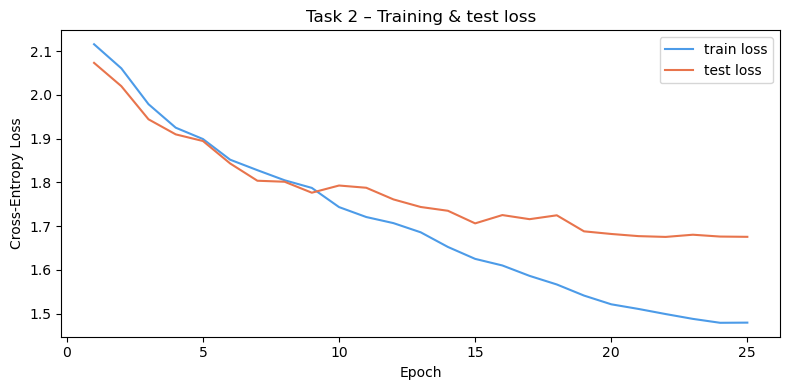

In [96]:
def train_transformer(model, train_loader, test_loader, criterion, optimizer, epochs=200, device=DEVICE):
    train_losses, test_losses = [], []

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in tqdm(range(1, epochs + 1), desc="Training... ", leave=True):
        model.train()
        total_train_loss = 0.
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() * x_batch.size(0)
        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        scheduler.step()

        model.eval()
        total_test_loss = 0.
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                logits = model(x_batch)
                loss = criterion(logits, y_batch)
                total_test_loss += loss.item() * x_batch.size(0)
        avg_test_loss = total_test_loss / len(test_loader.dataset)
        test_losses.append(avg_test_loss)
        
        if epoch % 20 == 0 and epochs >= 100:
            print(f"Epoch {epoch}/{epochs}  │  Train Loss: {avg_train_loss:.4f}  │  Test Loss: {avg_test_loss:.4f}")
        else:
            tqdm.write(f"Epoch {epoch}/{epochs}  │  Train Loss: {avg_train_loss:.4f}  │  Test Loss: {avg_test_loss:.4f}")

    return train_losses, test_losses

model = PatchTransformer(input_dim=192, emb_dim=64, num_heads=4, num_layers=3, num_classes=train_dataset.num_classes, dropout=0.5).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
train_losses, test_losses = train_transformer(model, train_dataloader, test_dataloader, criterion, optimizer, epochs=25, device=DEVICE)

# ── Loss curve ──
fig, ax = plt.subplots(figsize=(8, 4))
epochs = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, label='train loss', color='#4C9BE8', linewidth=1.5)
ax.plot(epochs, test_losses,  label='test loss',  color='#E8744C', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Task 2 – Training & test loss')
ax.legend()
plt.tight_layout()
plt.show()


# ── Save trained model ──
SAVE_PATH = "task2_patch_transformer.pt"
torch.save({
    "model_state": model.state_dict(),
    "hyperparams": {
        "input_dim": 192,
        "emb_dim": 64,
        "num_heads": 4,
        "num_layers": 3,
        "num_classes": train_dataset.num_classes,
        "dropout": 0.5
    },
    "train_losses": train_losses,
    "test_losses": test_losses,
}, SAVE_PATH)

In [103]:
# Load trained model (run this instead of the training cell)
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
hp = checkpoint["hyperparams"]
model = PatchTransformer(
    input_dim=hp["input_dim"],
    emb_dim=hp["emb_dim"],
    num_heads=hp["num_heads"],
    num_layers=hp["num_layers"],
    num_classes=hp["num_classes"],
    dropout=hp["dropout"]
).to(DEVICE)
model.load_state_dict(checkpoint["model_state"])

/tmp/ipykernel_329439/41935624.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)


<All keys matched successfully>

Classification Report:
                precision    recall  f1-score   support

       person       0.38      0.27      0.31        30
        rider       0.16      0.17      0.16        30
          car       0.32      0.23      0.27        30
        truck       0.32      0.27      0.29        30
          bus       0.23      0.30      0.26        30
         bike       0.34      0.40      0.37        30
traffic light       0.63      0.73      0.68        30
 traffic sign       0.66      0.70      0.68        30

     accuracy                           0.38       240
    macro avg       0.38      0.38      0.38       240
 weighted avg       0.38      0.38      0.38       240



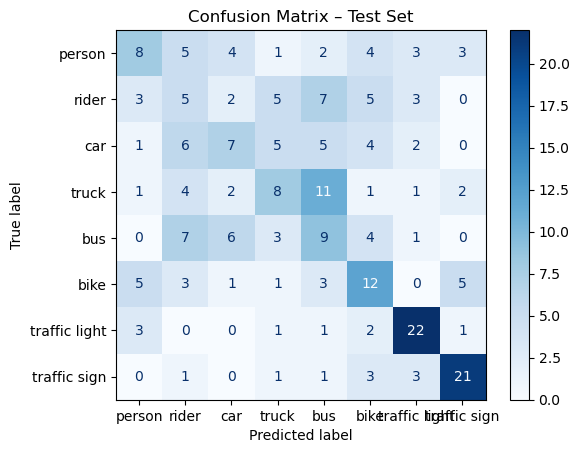

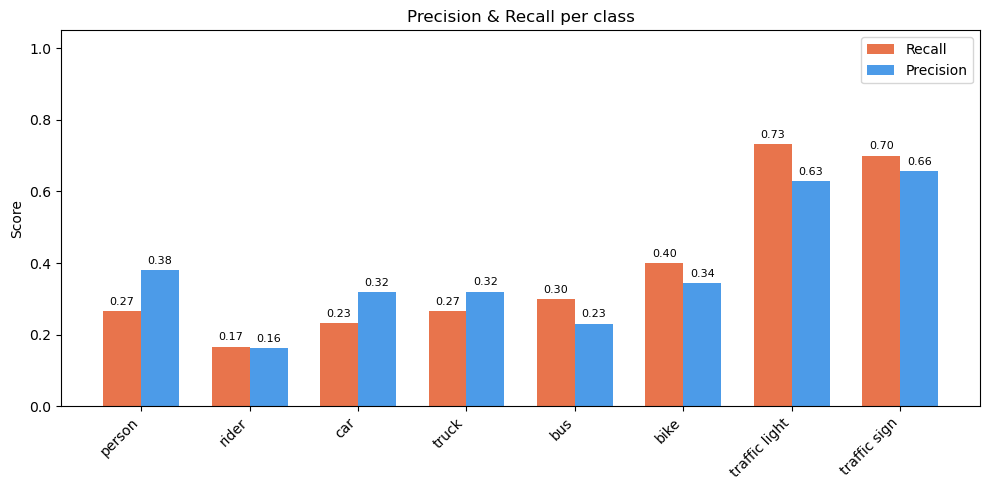

In [ ]:
# ==═════════════════════════════════════════════════════════════════════════════
# STEP 4 – Evaluation & single metrics figure
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

def evaluate_model(model, loader, device=DEVICE):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            probs = torch.softmax(logits, dim=-1)[:, 1]  # Probability of class 1 (drowsy)
            preds = torch.argmax(logits, dim=-1)
            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())
    all_probs = torch.cat(all_probs).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return all_probs, all_preds, all_labels 

probs, preds, labels = evaluate_model(model, test_dataloader)


# Evaluatiion report
eval_report = classification_report(labels, preds, target_names=test_dataset.classes, zero_division=0)
print("Classification Report:\n", eval_report)


# Confusion matrix
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Test Set')
plt.show()

# Plot of precision and recall per class
class_names = test_dataset.classes
precisions = precision_score(labels, preds, average=None, zero_division=0)
recalls = recall_score(labels, preds, average=None, zero_division=0)

x = np.arange(len(class_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, recalls, width, label='Recall', color='#E8744C')
rects2 = ax.bar(x + width/2, precisions, width, label='Precision', color='#4C9BE8')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Precision & Recall per class')
ax.legend()
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## Task 3 

In [ ]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()
        self.backbone = None  # Here you can use a function that creates the backbone model based on the backbone_arch string (take a look here: https://docs.pytorch.org/vision/main/models.html)

        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.

        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.

        # TODO: define the trainable linear classification head
        self.linear_head = None

    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.

        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        pass